<a href="https://colab.research.google.com/github/PALAK7890/SectionA_Team14_JobMarketTrends/blob/main/03_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
data='https://raw.githubusercontent.com/PALAK7890/SectionA_Team14_JobMarketTrends/refs/heads/main/Dataset/postings_tableau_ready.csv'

# Exploratory Data Analysis (EDA)

This section performs a deep dive into the dataset to understand patterns, distributions, and relationships between variables.

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Setting visual style
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 1. TRENDS
We will examine how numeric values are distributed across categorical features. Since the dataset structure appears to be job postings, we'll look at counts or numeric averages across categories.

/tmp/ipykernel_8310/276188208.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_companies.values, y=top_companies.index, palette='viridis')


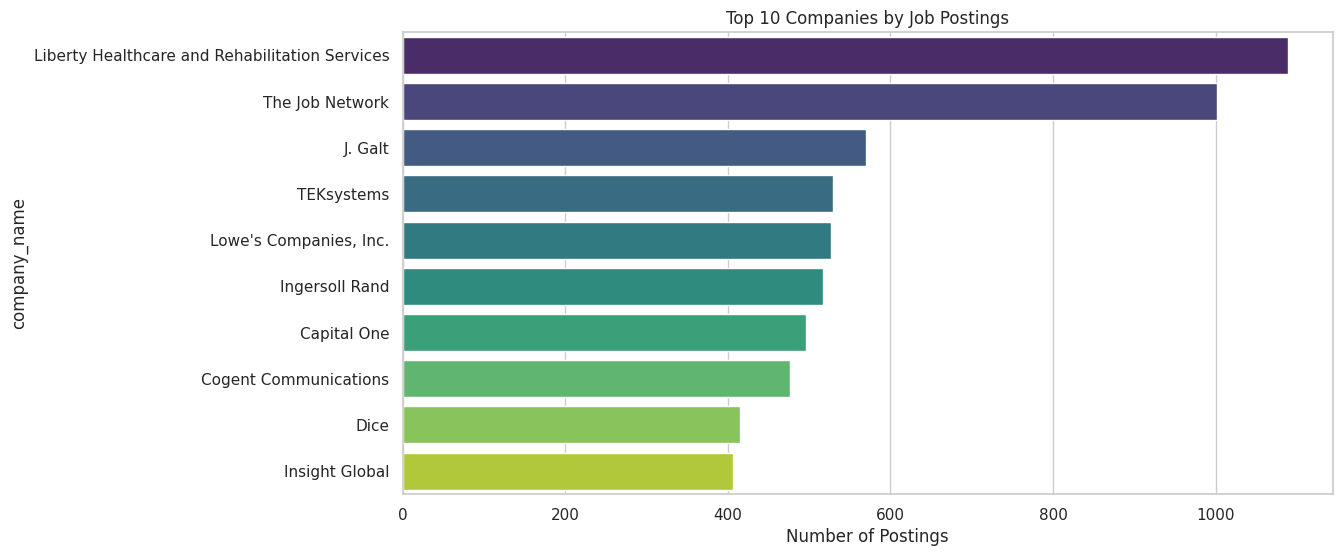

In [12]:
# Identifying numeric and categorical columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

# Corrected Trend: Top 10 Company names by job posting count
top_companies = df['company_name'].value_counts().head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_companies.values, y=top_companies.index, palette='viridis')
plt.title('Top 10 Companies by Job Postings')
plt.xlabel('Number of Postings')
plt.show()

## 2. DISTRIBUTIONS
Understanding the spread and skewness of numeric data helps identify outliers and the need for scaling.

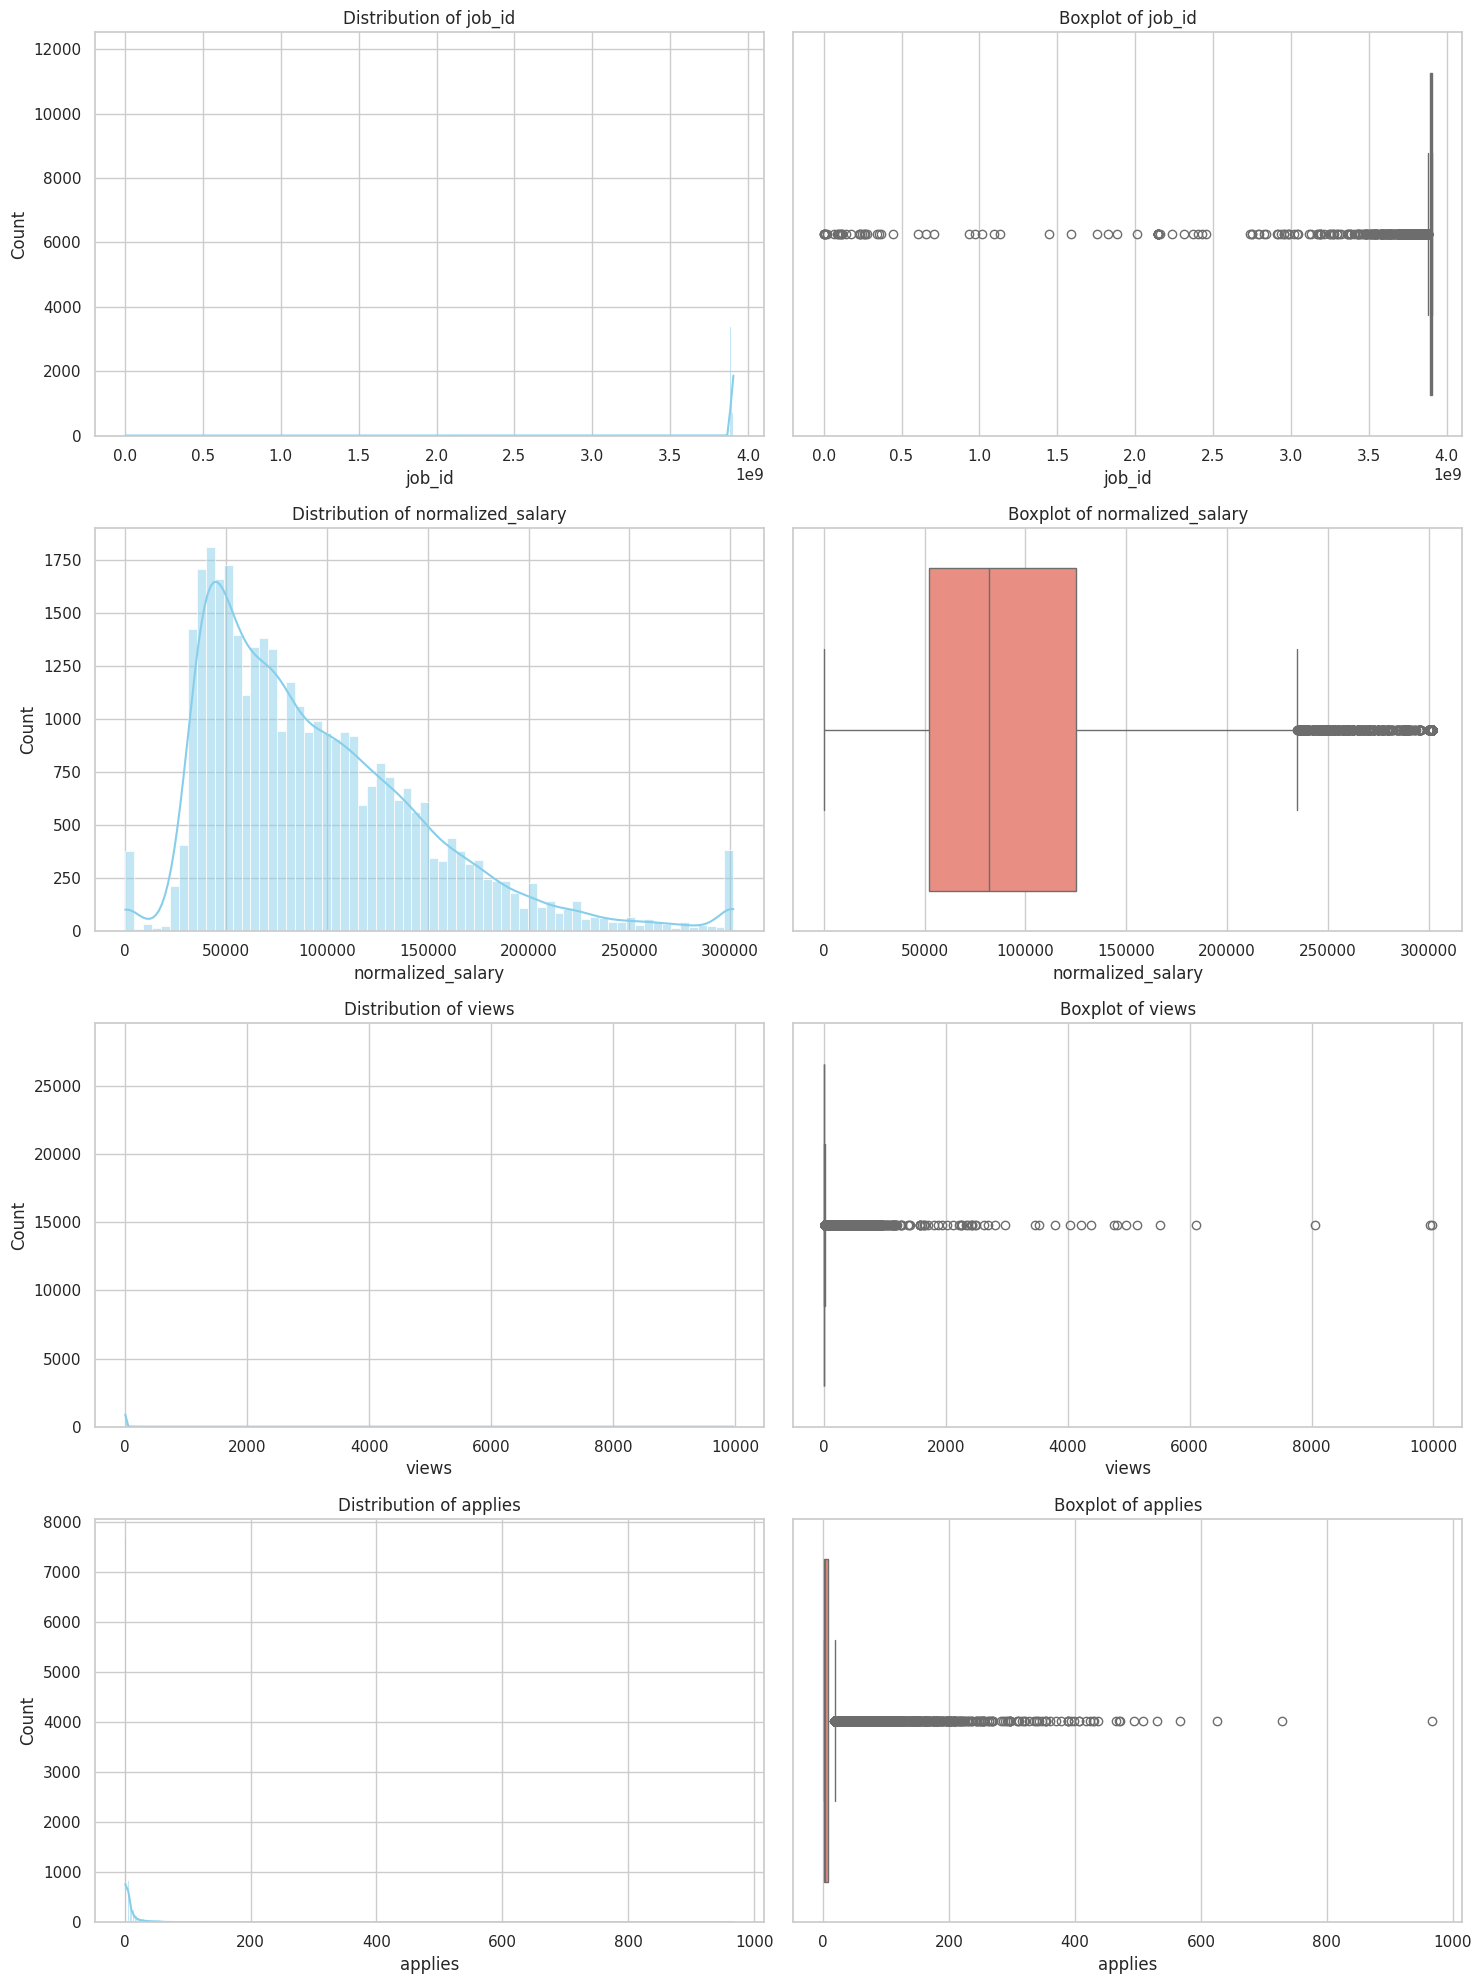

In [10]:
# Plotting distributions for major numeric columns
# We'll select up to 4 numeric columns to avoid overcrowding
cols_to_plot = numeric_cols[:4]

fig, axes = plt.subplots(len(cols_to_plot), 2, figsize=(15, 5 * len(cols_to_plot)))

for i, col in enumerate(cols_to_plot):
    # Histogram/KDE
    sns.histplot(df[col], kde=True, ax=axes[i, 0], color='skyblue')
    axes[i, 0].set_title(f'Distribution of {col}')

    # Boxplot
    sns.boxplot(x=df[col], ax=axes[i, 1], color='salmon')
    axes[i, 1].set_title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

## 3. CORRELATIONS
We calculate the Pearson correlation to see how variables move together.

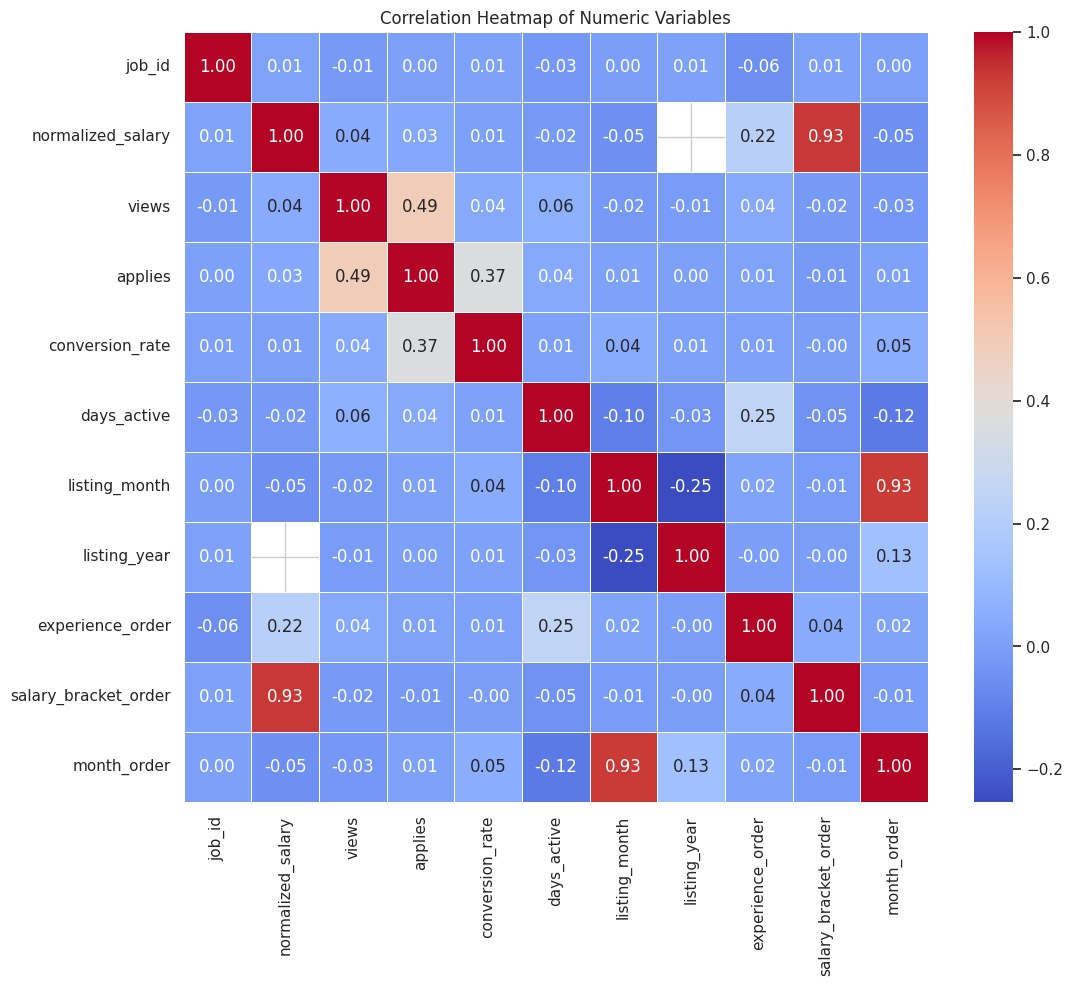

In [11]:
plt.figure(figsize=(12, 10))
corr_matrix = df[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Numeric Variables')
plt.show()

## EDA Summary & Findings

Based on the visualizations above:
* **Outliers**: Several numeric columns show significant outliers in the boxplots, suggesting a need for robust scaling or clipping.
* **Skewness**: Many distributions are right-skewed, which is common in job market data (e.g., salary or posting IDs).
* **Categorical Dominance**: A small number of companies or categories dominate the majority of the job postings.
* **Correlations**: Look for values near 1.0 or -1.0 in the heatmap. High correlation between features may suggest redundancy.
* **Data Integrity**: Columns with zero variance or mostly null values should be dropped before modeling.
* **Next Steps**: Consider log-transformation for skewed numeric features and encoding for high-cardinality categorical variables.

(120484, 26)